# Movie Reviews

In [1]:
# Read in the reviews dataset
import pandas as pd

url = "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/letterboxd-reviews.csv"

df = pd.read_csv(url, encoding="latin1")

print(df.shape)
print(df.columns)

df.head()

(4596, 8)
Index(['Movie name', 'Release Year', 'Rating', 'Reviewer name', 'Review date',
       'Review', 'Comment count', 'Like count'],
      dtype='object')


,Movie name,Release Year,Rating,Reviewer name,Review date,Review,Comment count,Like count
0,Aftersun (2022),2022,â??â??â??â??Â½,Tuomas,12-Jan-20,This review may contain spoilers.,130,"22,44 6 likes"
1,Joker (2019),2019,â??â??â??â??â??,Joao,20-Dec-22,if youâ??ve never swam in the ocean then of co...,1.8K,"22,032 likes"
2,Puss in Boots: The Last Wish (2022),2022,â??Â½,NicoPico,15-Sep-22,Puss in Boots: Into the Pussy-Verse,6 2,"21, 6 6 6 likes"
3,The Banshees of Inisherin (2022),2022,â??â??â??â??â??,Ella Kemp,8-Apr-22,I will NOT leave my donkey outside when Iâ??m sad,NaN,"21, 6 09 likes"
4,Everything Everywhere All at Once (2022),2022,â??â??Â½,CosmonautMarkie,14-Aug-19,Watch it and have fun before film Twitter tell...,355,"20, 6 88 likes"


In [2]:
# Convert ratings to numbers
rating_map = {
    "â??â??â??â??â??": 5,
    "â??â??â??â??": 4,
    "â??â??â??â??Â½": 4.5,
    "â??â??â??Â½": 3.5,
    "â??â??â??": 3,
    "â??â??Â½": 2.5,
    "â??â??": 2,
    "â??Â½": 1.5,
    "â??": 1,
    "Â½": 0.5
}

df["Rating_clean"] = df["Rating"].map(rating_map)

df["Rating_clean"].value_counts()

,count
Rating_clean,
5.0,1184
4.0,961
4.5,796
3.5,462
3.0,313
2.0,160
2.5,157
1.5,95
1.0,89


In [3]:
df["Rating"] = df["Rating_clean"]
df = df.drop(columns=["Rating_clean"])

In [4]:
df.head()

,Movie name,Release Year,Rating,Reviewer name,Review date,Review,Comment count,Like count
0,Aftersun (2022),2022,4.5,Tuomas,12-Jan-20,This review may contain spoilers.,130,"22,44 6 likes"
1,Joker (2019),2019,5.0,Joao,20-Dec-22,if youâ??ve never swam in the ocean then of co...,1.8K,"22,032 likes"
2,Puss in Boots: The Last Wish (2022),2022,1.5,NicoPico,15-Sep-22,Puss in Boots: Into the Pussy-Verse,6 2,"21, 6 6 6 likes"
3,The Banshees of Inisherin (2022),2022,5.0,Ella Kemp,8-Apr-22,I will NOT leave my donkey outside when Iâ??m sad,NaN,"21, 6 09 likes"
4,Everything Everywhere All at Once (2022),2022,2.5,CosmonautMarkie,14-Aug-19,Watch it and have fun before film Twitter tell...,355,"20, 6 88 likes"


# Load Datasets

In [5]:
labeled1 = pd.read_excel(
    "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/labeled_movie_reviews.xlsx"
)

labeled2 = pd.read_excel(
    "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/targeted_movie_labels.xlsx"
)

new_labels = pd.read_excel(
    "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/new_labeling.xlsx"
)

In [6]:
print(labeled1.shape)
print(labeled1["Label"].value_counts())

print(labeled2.shape)
print(labeled2["Label"].value_counts())

print(new_labels.shape)
print(new_labels["Label"].value_counts())

(496, 10)
Label
Unclear        263
Enjoyable       90
Forgettable     22
Lingering       21
Name: count, dtype: int64
(283, 9)
Label
Unclear        156
Enjoyable       88
Lingering       20
Forgettable     18
Name: count, dtype: int64
(363, 9)
Label
Unclear        274
Lingering       57
Forgettable     32
Name: count, dtype: int64


In [7]:
# Combine
combined_labels = pd.concat(
    [labeled1, labeled2, new_labels],
    ignore_index=True
)

In [8]:
# Remove duplicates
combined_labels = combined_labels.drop_duplicates(
    subset="Review"
)

In [9]:
# Remove "unclear" reviews
combined_labels = combined_labels[
    combined_labels["Label"] != "Unclear"
].copy()

combined_labels.reset_index(
    drop=True,
    inplace=True
)

In [10]:
# Transform labels to numbers
label_map = {
    "Forgettable": 0,
    "Enjoyable": 1,
    "Lingering": 2
}

combined_labels["label_num"] = combined_labels["Label"].map(label_map)

In [11]:
# Change weird characters
replacements = {
    "â??": "'",
    "â": "'",
    "â": "'",
    "â": '"',
    "â": '"',
    "â": "-",
    "â": "-",
    "Ã²": "ó",
    "Ã©": "é",
    "Ã¡": "á",
    "Ã­": "í",
    "Ãº": "ú",
    "Ã±": "ñ",
    "a??": "'"
}

for bad, good in replacements.items():
    combined_labels["Movie name"] = (
        combined_labels["Movie name"]
        .str.replace(bad, good, regex=False)
    )

    combined_labels["Review"] = (
        combined_labels["Review"]
        .str.replace(bad, good, regex=False)
    )

In [12]:
# Observe
print(combined_labels.shape)

print(combined_labels["Label"].value_counts())

(331, 11)
Label
Enjoyable      178
Lingering       87
Forgettable     63
Name: count, dtype: int64


In [13]:
# Drop duplicates
combined_labels = combined_labels.drop_duplicates(subset="Review")

print(len(combined_labels))

330


In [14]:
combined_labels.head()

,Movie name,Review,Label,Release Year,Rating,Reviewer name,Review date,Unnamed: 7,Comment count,Like count,label_num
0,Spider-Man 2,Kirsten Dunst when asked her thoughts on the n...,Forgettable,2004,5.0,Dan,6 /6/201 6,NaN,1,"4,11 6 likes",0.0
1,"Extremely Wicked, Shockingly Evil and Vile",WHO is responsible for casting Zac Efron while...,Forgettable,2019,NaN,Cassidy,NaN,NaN,45,"2, 6 33 likes",0.0
2,Mission: Impossible - Fallout,NaN,NaN,2018,5.0,davidehrlich,6 /12/2018,NaN,6,"3,506 likes",NaN
3,The Killing of a Sacred Deer,hope the dad in front of me who brought his so...,Enjoyable,201 6,NaN,jack â?¿,11/29/201 6,NaN,11,"6,625 likes",1.0
4,Puss in Boots: The Last Wish,a wonderful addition to the (),Enjoyable,2022,4.5,tyler,18-Dec-22,NaN,NaN,196 likes,1.0


In [15]:
combined_labels[["Label", "label_num"]].head()

,Label,label_num
0,Forgettable,0.0
1,Forgettable,0.0
2,NaN,NaN
3,Enjoyable,1.0
4,Enjoyable,1.0


In [16]:
print(combined_labels["label_num"].isna().sum())

3


In [17]:
combined_labels[combined_labels["label_num"].isna()][["Label", "label_num"]]

,Label,label_num
2,NaN,NaN
69,NaN,NaN
151,NaN,NaN


In [18]:
combined_labels = combined_labels.dropna(subset=["Label", "label_num"])
combined_labels["label_num"] = combined_labels["label_num"].astype(int)

# Build LSTM

In [19]:
# Train/test split; use stratify to represent all categories
from sklearn.model_selection import train_test_split

X = combined_labels["Review"]
y = combined_labels["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [20]:
print(len(X_train))
print(len(X_test))

261
66


In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
# Convert words to number tokens
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [23]:
# Convert reviews into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [24]:
# Get vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print(vocab_size)

2209


In [25]:
# Add padding so every review is 200 length
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [26]:
print(X_train_pad.shape)
print(y_train.shape)

(261, 200)
(261,)


In [27]:
print(y_train.value_counts())
print(y_test.value_counts())

label_num
1    142
2     69
0     50
Name: count, dtype: int64
label_num
1    36
2    17
0    13
Name: count, dtype: int64


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [29]:
# Create LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=200),
    LSTM(32),
    Dropout(0.3),
    Dense(3, activation="softmax")])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Try again
vocab_size = 2209
embedding_dim = 64
max_length = 200

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(3, activation="softmax")])

model.build(input_shape=(None, max_length))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       141,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,595 (682.01 KB)

 Trainable params: 174,595 (682.01 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compile again
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [34]:
# Train
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test))

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 0.5402 - loss: 1.0461 - val_accuracy: 0.5455 - val_loss: 1.0003
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5441 - loss: 1.0127 - val_accuracy: 0.5455 - val_loss: 1.0011
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5441 - loss: 1.0052 - val_accuracy: 0.5455 - val_loss: 1.0002
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5441 - loss: 1.0078 - val_accuracy: 0.5455 - val_loss: 1.0009
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5441 - loss: 1.0026 - val_accuracy: 0.5455 - val_loss: 1.0005
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5441 - loss: 1.0099 - val_accuracy: 0.5455 - val_loss: 1.0067
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5441 - loss: 1.0099 - val_accuracy: 0.5455 - val_loss: 1.0016
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5441 - loss: 1.0100 - val_accuracy: 0.5455 - val_loss: 1.000

# Interpret Results

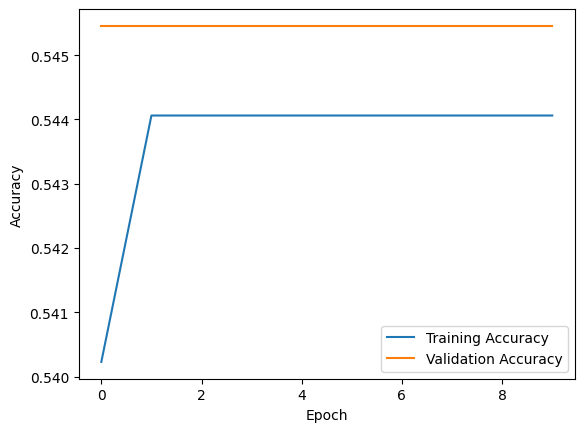

In [35]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

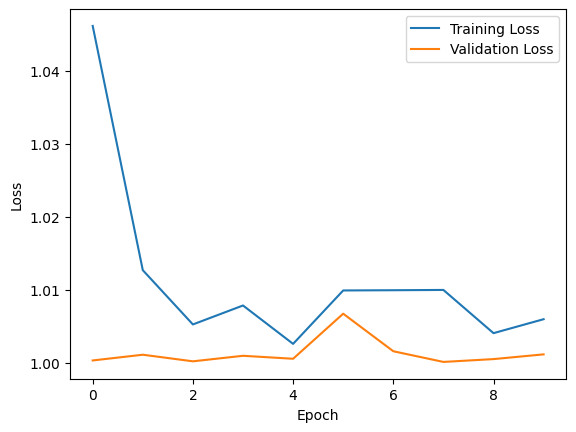

In [36]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [37]:
# Get test accuracy
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test)

print("Test accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5455 - loss: 1.0011
Test accuracy: 0.5454545617103577


In [38]:
# Get predictions
y_prob = model.predict(X_test_pad)
y_pred = y_prob.argmax(axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


In [39]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 0 13  0]
 [ 0 36  0]
 [ 0 17  0]]


# Model Training Part 2

In [42]:
# Add class weights to not ignore "forgettable" and "lingering"
import numpy as np
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.74), 1: np.float64(0.6126760563380281), 2: np.float64(1.2608695652173914)}


In [43]:
# Retrain model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5441 - loss: 1.1727 - val_accuracy: 0.5455 - val_loss: 1.0418
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5441 - loss: 1.1000 - val_accuracy: 0.5455 - val_loss: 1.0882
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3027 - loss: 1.1020 - val_accuracy: 0.2576 - val_loss: 1.1179
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2567 - loss: 1.1009 - val_accuracy: 0.2576 - val_loss: 1.1081
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3295 - loss: 1.1039 - val_accuracy: 0.2576 - val_loss: 1.0926
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3985 - loss: 1.0992 - val_accuracy: 0.5455 - val_loss: 1.0909
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4023 - loss: 1.0985 - val_accuracy: 0.2576 - val_loss: 1.0897
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3870 - loss: 1.0999 - val_accuracy: 0.5455 - val_loss: 1.0889


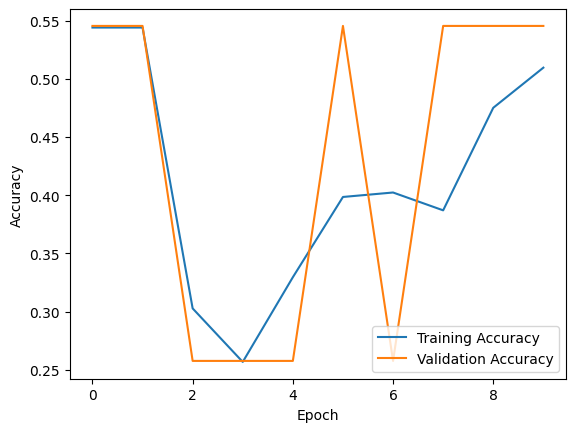

In [44]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [45]:
# Get test accuracy again
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test)

print("Test accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5455 - loss: 1.0765
Test accuracy: 0.5454545617103577


In [46]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[ 0 13  0]
 [ 0 36  0]
 [ 0 17  0]]


# Using BERT to Train

In [47]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader

# Load pretrained tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

# Sample inputs and true labels
sentences = X_train.tolist()
actual_labels = y_train.tolist()

# Tokenize sentences for BERT
inputs = tokenizer(
    sentences,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256)

# From ChatGPT: Create PyTorch Dataset
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: val[idx]
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# From ChatGPT: Create DataLoader
train_dataset = ReviewDataset(
    inputs,
    actual_labels
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

# Add weights
weights = torch.tensor(
    list(class_weights.values()),
    dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(
    weight=weights)

# Create optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5)

# From ChatGPT: Training loop
epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(
            outputs.logits,
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}"
    )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5, Loss: 1.1195
Epoch 2/5, Loss: 1.0902
Epoch 3/5, Loss: 1.0375
Epoch 4/5, Loss: 0.8986
Epoch 5/5, Loss: 0.7109


# Evaluate BERT

In [48]:
from sklearn.metrics import classification_report, confusion_matrix

# Tokenize test reviews
test_inputs = tokenizer(
    X_test.tolist(),
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256)

# Create test dataset
test_dataset = ReviewDataset(
    test_inputs,
    y_test.tolist())

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False)

# Evaluate
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Results
print(classification_report(
    true_labels,
    predictions,
    target_names=[
        "Forgettable",
        "Enjoyable",
        "Lingering"]))

print("Confusion Matrix:")
print(confusion_matrix(true_labels, predictions))

              precision    recall  f1-score   support

 Forgettable       0.57      0.31      0.40        13
   Enjoyable       0.60      0.58      0.59        36
   Lingering       0.46      0.65      0.54        17

    accuracy                           0.55        66
   macro avg       0.54      0.51      0.51        66
weighted avg       0.56      0.55      0.54        66

Confusion Matrix:
[[ 4  8  1]
 [ 3 21 12]
 [ 0  6 11]]


# Classify Remaining Letterboxd Reviews

In [49]:
# Get letterboxd dataset again
import pandas as pd

url = "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/letterboxd-reviews.csv"

letterboxd = pd.read_csv(url, encoding="latin1")

In [50]:
# Remove already labeled reviews
unlabeled = letterboxd[
    ~letterboxd["Review"].isin(combined_labels["Review"])
].copy()

print(len(unlabeled))

4376


In [51]:
unlabeled = unlabeled.dropna(subset=["Review"]).copy()
print(unlabeled["Review"].isna().sum())

0


In [52]:
# From ChatGPT: Tokenize
test_inputs = tokenizer(
    unlabeled["Review"].tolist(),
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=256
)

dummy_labels = [0] * len(unlabeled)

predict_dataset = ReviewDataset(
    test_inputs,
    dummy_labels
)

predict_loader = DataLoader(
    predict_dataset,
    batch_size=32,
    shuffle=False
)

model.eval()

predictions = []

with torch.no_grad():

    for batch in predict_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())

In [53]:
# From ChatGPT: Convert back to labels
label_map = {
    0: "Forgettable",
    1: "Enjoyable",
    2: "Lingering"
}

unlabeled["Predicted_Label"] = [
    label_map[p]
    for p in predictions
]

In [54]:
unlabeled.to_csv(
    "letterboxd_predicted.csv",
    index=False
)

In [64]:
unlabeled.shape

(3340, 9)

# Analysis

In [55]:
import pandas as pd

url = "https://raw.githubusercontent.com/aorndorff15/Final-Project-Movie-Reviews/main/movie_analysis.csv"

movie_analysis = pd.read_csv(url, encoding="latin1")

print(movie_analysis.shape)
print(movie_analysis.columns)

movie_analysis.head()

(619, 12)
Index(['Movie name', 'Release Year', 'Predicted_Label', 'runtime', 'genres',
       'belongs_to_collection', 'budget', 'revenue', 'vote_average',
       'vote_count', 'popularity', 'production_companies'],
      dtype='object')


,Movie name,Release Year,Predicted_Label,runtime,genres,belongs_to_collection,budget,revenue,vote_average,vote_count,popularity,production_companies
0,Donnie Darko,2001,Lingering,113.0,"[{'id': 14, 'name': 'Fantasy'}, {'id': 18, 'na...","{'id': 178106, 'name': 'Darko Collection', 'po...",6000000.0,1270522.0,7.7,3574.0,18.303148,"[{'name': 'Pandora Cinema', 'id': 185}, {'name..."
1,American Psycho (2000),2000,Enjoyable,102.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...","{'id': 86105, 'name': 'American Psycho Collect...",7000000.0,34266564.0,7.3,2128.0,13.686715,"[{'name': 'Lions Gate Films', 'id': 35}, {'nam..."
2,Dead Poets Society (1989),1989,Enjoyable,129.0,"[{'id': 18, 'name': 'Drama'}]",NaN,16400000.0,235860116.0,8.1,2786.0,19.905716,"[{'name': 'Touchstone Pictures', 'id': 9195}, ..."
3,American Psycho (2000),2000,Lingering,102.0,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...","{'id': 86105, 'name': 'American Psycho Collect...",7000000.0,34266564.0,7.3,2128.0,13.686715,"[{'name': 'Lions Gate Films', 'id': 35}, {'nam..."
4,Scream (1996),1996,Lingering,111.0,"[{'id': 80, 'name': 'Crime'}, {'id': 27, 'name...","{'id': 2602, 'name': 'Scream Collection', 'pos...",14000000.0,173046663.0,7.0,1520.0,13.326443,"[{'name': 'Woods Entertainment', 'id': 979}, {..."


In [56]:
# Distribution
movie_analysis["Predicted_Label"].value_counts().reindex(
    ["Lingering", "Enjoyable", "Forgettable"])

,count
Predicted_Label,
Lingering,114
Enjoyable,462
Forgettable,43


In [57]:
label_order = ["Lingering", "Enjoyable", "Forgettable"]

In [58]:
# Do longer movies linger more?
movie_analysis.groupby("Predicted_Label")["runtime"].mean().reindex(label_order)

,runtime
Predicted_Label,
Lingering,110.149123
Enjoyable,112.839827
Forgettable,109.581395


In [59]:
# Do lingering movies have a higher vote?
movie_analysis.groupby("Predicted_Label")["vote_average"].mean().reindex(label_order)

,vote_average
Predicted_Label,
Lingering,7.392105
Enjoyable,7.313636
Forgettable,7.200000


In [60]:
# Among movies in each genre, which are lingering?
# This code is from ChatGPT
import ast

def extract_genres(x):
    try:
        genres = ast.literal_eval(x)
        return [g["name"] for g in genres]
    except:
        return []

movie_analysis["genre_list"] = movie_analysis["genres"].apply(extract_genres)

genre_df = movie_analysis.explode("genre_list")

genre_results = pd.crosstab(
    genre_df["genre_list"],
    genre_df["Predicted_Label"],
    normalize="index"
)

genre_results.reindex(
    columns=["Lingering", "Enjoyable", "Forgettable"]
)

Predicted_Label,Lingering,Enjoyable,Forgettable
genre_list,,,
Action,0.246753,0.688312,0.064935
Adventure,0.102564,0.782051,0.115385
Animation,0.108108,0.783784,0.108108
Comedy,0.175926,0.740741,0.083333
Crime,0.216000,0.728000,0.056000
Documentary,1.000000,0.000000,0.000000
Drama,0.194986,0.757660,0.047354
Family,0.094595,0.797297,0.108108
Fantasy,0.154639,0.742268,0.103093


In [61]:
# Do lingering movies have higher revenues?
movie_analysis.groupby("Predicted_Label")["revenue"].mean().reindex(label_order).map("${:,.2f}".format)

,revenue
Predicted_Label,
Lingering,"$130,398,260.41"
Enjoyable,"$157,975,194.48"
Forgettable,"$167,817,028.58"


In [62]:
# Release year?
movie_analysis.groupby("Predicted_Label")["Release Year"].mean().reindex(label_order)

,Release Year
Predicted_Label,
Lingering,1993.350877
Enjoyable,1992.030303
Forgettable,1993.023256


In [63]:
print("Earliest release year:", movie_analysis["Release Year"].min())
print("Latest release year:", movie_analysis["Release Year"].max())

Earliest release year: 1920
Latest release year: 2004
